GEOGCS["Undefined geographic SRS",DATUM["unknown",SPHEROID["unknown",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
[ 219936.     5752581.     5125574.     7667746.9994]
28078


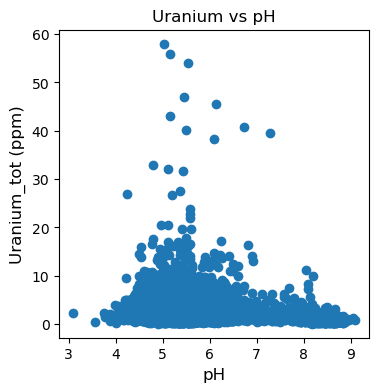

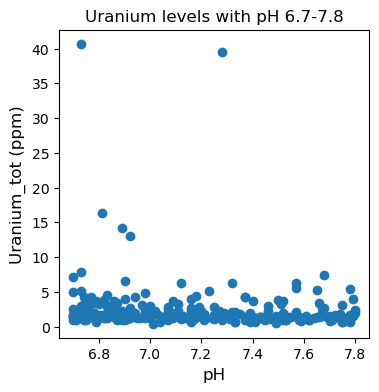

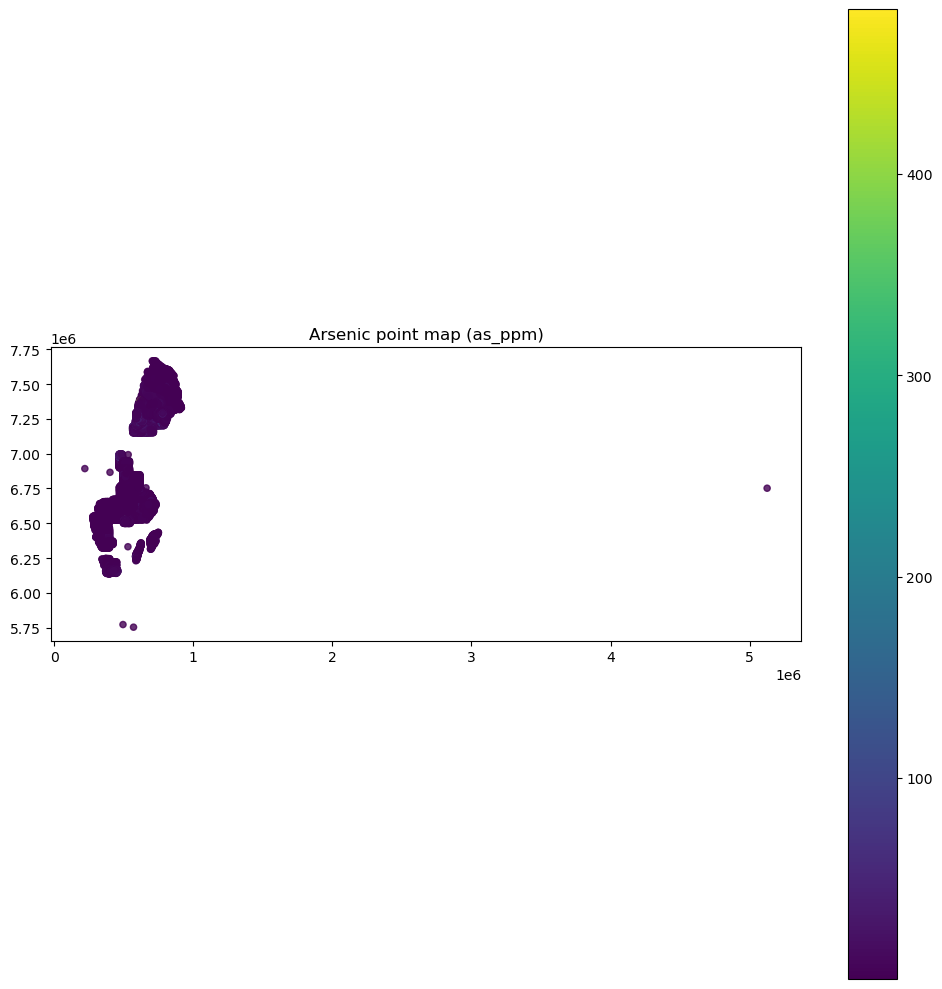

In [7]:
import geopandas as gpd

#Uranium moran_0063mm_ph 

#missing data included
markgeokemi_icpms_NaN = gpd.read_file("markgeokemi_regional.gpkg", layer = "moran_0063mm_hno3_icpms")
markgeokemi_icpms_NaN.head()
#search dataframa columns and return those related to u_, 
#col.lower(): convert all uppercase characters in a string column to lowercase
[col for col in markgeokemi_icpms_NaN.columns if "u_ppm" in col.lower()] 
#takes 7 col & stores in a new variable ars. copy(). NaN included
u_ppm_icpms = markgeokemi_icpms_NaN[["unikt_id", "geometry","ns", "ew", "prov_artal","provtyp", "u_ppm"]].copy()
#No NaN: use notna.() when you choose only one element, dropna.() remove all rows with NaN
u_ppm_icpms=u_ppm_icpms.dropna(subset=["u_ppm"])

#pH moran_0063mm_ph 

#missing data included 
ph= gpd.read_file("markgeokemi_regional.gpkg", layer = "moran_0063mm_ph")
ph.head()
#search dataframa columns and return those related to ph, 
#col.lower(): convert all uppercase characters in a string column to lowercase
[col for col in ph.columns if "ph" in col.lower()] 
#takes 7 col & stores in a new variable ph. copy(). NaN included
ph = ph[["unikt_id","geometry","ns", "ew", "prov_artal","provtyp", "ph"]].copy() 
#No NaN: use notna.() when you choose only one element, dropna.() remove all rows with NaN
ph=ph.dropna(subset=["ph"])


# Merge unikt_id**
merged_u_ppm_and_ph= u_ppm_icpms.merge(ph[["unikt_id", "ph"]], on= "unikt_id", how= "inner", validate = "one_to_one") ##on="unikt_id", 
#u_pmm_icpms, left table, Match uranium rows with pH rows using common sample IDs (Match rows where: u_ppm_icpms.unikt_id == ph.unikt_id)
#how="inner": Keep only rows present in BOTH tables, validate="one_to_one": Every unikt_id must appear only once in each table

#print(merged_u_ppm_and_ph.head())

#Uranium vs pH


import matplotlib.pyplot as plt

#Scatter plot: pH on X-axis vs Uranium on Y-axis

plt.figure(figsize= (4,4))
plt.scatter(merged_u_ppm_and_ph["ph"] , merged_u_ppm_and_ph["u_ppm"])
plt.title("Uranium vs pH", fontsize= 12)
plt.xlabel("pH", fontsize= 12)
plt.ylabel("Uranium_tot (ppm)", fontsize =12)
#plt.savefig("Uranium_pH.png",  dpi=300, bbox_inches="tight")
#plt.show()


#within pH range 6-8.5
u_ph_private_well= merged_u_ppm_and_ph[merged_u_ppm_and_ph["ph"].between(6.7, 7.8, inclusive= "both")].copy()


#print("filtered ph 6-8.5 shape:", u_ph_private_well.shape)

#Scatter plot: pH on X-axis vs Uranium on Y-axis
plt.figure(figsize= (4,4))
plt.scatter(u_ph_private_well["ph"] , u_ph_private_well["u_ppm"])
plt.title("Uranium levels with pH 6.7-7.8", fontsize= 12)
plt.xlabel("pH", fontsize= 12)
plt.ylabel("Uranium_tot (ppm)", fontsize =12)
#plt.savefig("Uranium_in_private_well_pH.png",  dpi=300, bbox_inches="tight")
#plt.show()

#----------------------------------------------------------------------------------

